In [3]:
!pip install mediapipe opencv-python-headless

In [7]:
!wget -O face_landmarker.task -q https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task

In [11]:
!wget -O face_landmarker.task -q https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task

Tracking Complete | Yaw: 0 | Pitch: 1


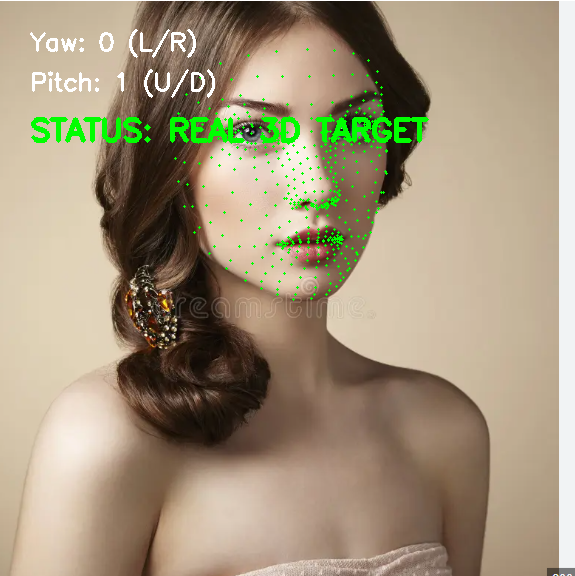

In [15]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 1. SETUP: Model download aur Configuration
# Agar model file nahi hai, toh pehle ye command run karein:
# !wget -O face_landmarker.task https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task

base_options = python.BaseOptions(model_asset_path='face_landmarker.task')
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    output_face_blendshapes=True,
    num_faces=1)
detector = vision.FaceLandmarker.create_from_options(options)

# 2. IMAGE LOADING
image_path = "test.jpg"  # Apni file ka naam yahan check karlo
cv_img = cv2.imread(image_path)

if cv_img is None:
    print(f"Error: {image_path} nahi mili. File upload karke naam sahi check karo.")
else:
    image_mp = mp.Image.create_from_file(image_path)
    h, w, _ = cv_img.shape

    # 3. DETECTION
    detection_result = detector.detect(image_mp)

    if detection_result.face_landmarks:
        face_landmarks = detection_result.face_landmarks[0]

        # --- POSE ESTIMATION LOGIC ---
        # 6 Key Landmarks Mapping (Nose, Chin, Eyes, Mouth)
        image_points = np.array([
            [face_landmarks[1].x * w, face_landmarks[1].y * h],      # Nose
            [face_landmarks[152].x * w, face_landmarks[152].y * h],  # Chin
            [face_landmarks[33].x * w, face_landmarks[33].y * h],    # L-Eye
            [face_landmarks[263].x * w, face_landmarks[263].y * h],  # R-Eye
            [face_landmarks[61].x * w, face_landmarks[61].y * h],    # L-Mouth
            [face_landmarks[291].x * w, face_landmarks[291].y * h]   # R-Mouth
        ], dtype="double")

        # Standard 3D Model Points (Human Face Geometry)
        model_points = np.array([
            (0.0, 0.0, 0.0),             # Nose tip
            (0.0, -330.0, -65.0),        # Chin
            (-225.0, 170.0, -135.0),     # Left eye corner
            (225.0, 170.0, -135.0),      # Right eye corner
            (-150.0, -150.0, -125.0),    # Left mouth corner
            (150.0, -150.0, -125.0)      # Right mouth corner
        ])

        # Camera Internals (Focal Length approximation)
        focal_length = w
        center = (w/2, h/2)
        camera_matrix = np.array([[focal_length, 0, center[0]],
                                [0, focal_length, center[1]],
                                [0, 0, 1]], dtype="double")

        # Solve PnP (Maps 2D to 3D)
        _, rvec, tvec = cv2.solvePnP(model_points, image_points, camera_matrix, np.zeros((4,1)))
        rmat, _ = cv2.Rodrigues(rvec)

        # Get Euler Angles
        angles, _, _, _, _, _, _ = cv2.decomposeProjectionMatrix(np.hstack((rmat, tvec)))
        pitch, yaw, roll = angles[0][0], angles[1][0], angles[2][0]

        # --- DRAWING & UI ---
        # Draw Mesh Dots (Optional: for visual feedback)
        for lm in face_landmarks:
            x, y = int(lm.x * w), int(lm.y * h)
            cv2.circle(cv_img, (x, y), 1, (0, 255, 0), -1)

        # Anti-Spoofing Status
        # Static photos usually have dead-center 0,0 angles
        is_spoof = abs(yaw) < 0.2 and abs(pitch) < 0.2
        status = "STATUS: SPOOF / STATIC" if is_spoof else "STATUS: REAL 3D TARGET"
        color = (0, 0, 255) if is_spoof else (0, 255, 0)

        # Overlay Info
        cv2.putText(cv_img, f"Yaw: {int(yaw)} (L/R)", (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)
        cv2.putText(cv_img, f"Pitch: {int(pitch)} (U/D)", (30, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)
        cv2.putText(cv_img, status, (30, 140), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 3)

        # Final Dashboard View
        print(f"Tracking Complete | Yaw: {int(yaw)} | Pitch: {int(pitch)}")
        cv2_imshow(cv_img)
    else:
        print("Face detection failed. Check image quality.")